# Implicit-Function Node: Recycle Streams and Algebraic Loops

Equation-oriented process models routinely contain **algebraic loops** — a
recycle stream whose flow depends on a reactor output that in turn depends on the
recycle. Such a variable is defined only *implicitly*, as the solution of a
square nonlinear system $g(u, v) = 0$ with no closed form {cite:p}`Biegler2010`.

discopt exposes these through **`m.implicit(...)`**: a vector $v$ defined by
$g(u, v) = 0$ is compiled to a *differentiable inner solve* — a Newton iteration
for the forward map, and **implicit-function-theorem** derivatives for the
reverse, so the outer optimizer sees exact gradients without differentiating
through the Newton iterations {cite:p}`Blondel2022`. This is the core-side
primitive that lets reduced-space **variable aggregation** eliminate irreducible
*cyclic* blocks instead of leaving them in the model {cite:p}`Naik2025`.

```{note}
An implicitly-defined $\varphi(u)$ has no McCormick relaxation, so — like any
opaque AD-only node — a model containing `m.implicit` is solved on the **local
NLP path only** (no global optimality certificate), and integer variables are
rejected. It is a tool for *local* reduced-space solves, exactly the setting
where recycle loops arise.
```

In [1]:
import warnings

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import discopt.modeling as dm

warnings.filterwarnings("ignore")

## A reactor with recycle

Fresh feed $F_0$ of reactant A enters a mixer, joins a recycle stream $R$, and
passes through a reactor of volume $V$. For a first-order reaction the
single-pass conversion is $X = kV / (T + kV)$, where $T = F_0 + R$ is the total
reactor feed, so the unreacted flow leaving is $T\,(1 - X) = T^2/(T + kV)$. A
separator returns a fraction $\alpha$ of the unreacted A as recycle,
$R = \alpha\, T^2/(T + kV)$.

Substituting $R = T - F_0$ closes the loop into a single implicit equation for
the total reactor feed $T$ given the design variable $V$:

$$
g(T; V) \;=\; (T - F_0)\,(T + kV) \;-\; \alpha\,T^2 \;=\; 0 .
$$

There is no explicit $T(V)$ to substitute — this is precisely the irreducible
cyclic block that `m.implicit` handles. We choose the reactor volume $V$ to hit a
target throughput $T^\star = 18$, minimizing $(T - T^\star)^2$.

In [2]:
F0, k, alpha = 10.0, 0.5, 0.6   # feed (mol/s), rate constant (1/s), recycle fraction
T_target = 18.0


def recycle_residual(u, v):
    # u = [V] (design), v = [T] (implicit unknown): g(T; V) = 0
    V, T = u[0], v[0]
    return jnp.array([(T - F0) * (T + k * V) - alpha * T**2])


m = dm.Model()
V = m.continuous("V", lb=0.1, ub=50.0)
T = m.implicit(recycle_residual, [V], n_unknowns=1, x0=jnp.array([20.0]))
m.minimize((T[0] - T_target) ** 2)

r = m.solve(initial_solution={V: 5.0})
print(f"status        : {r.status}")
print(f"V*            : {float(r.x['V']):.4f}")
print(f"objective     : {r.objective:.3e}")
print(f"gap_certified : {getattr(r, 'gap_certified', False)}   (local NLP path — no global cert)")

status        : optimal
V*            : 12.6000
objective     : 3.187e-20
gap_certified : False   (local NLP path — no global cert)


The optimizer drove $V$ using the derivative $\mathrm{d}T/\mathrm{d}V$ that flows
through the implicit solve by the implicit-function theorem,
$\mathrm{d}T/\mathrm{d}V = -(\partial g/\partial T)^{-1}\,(\partial g/\partial V)$
— no differentiation through the Newton iterations.

## The forward map $T(V)$

Because $g$ is quadratic in $T$ here, we can also write the root in closed form
and use it to *verify* discopt's answer and to visualize the block $T(V)$ the
optimizer navigated.

analytic V for T=18 : 12.6000
discopt V*          : 12.6000
T(V*) check         : 18.0000  (target 18.0)


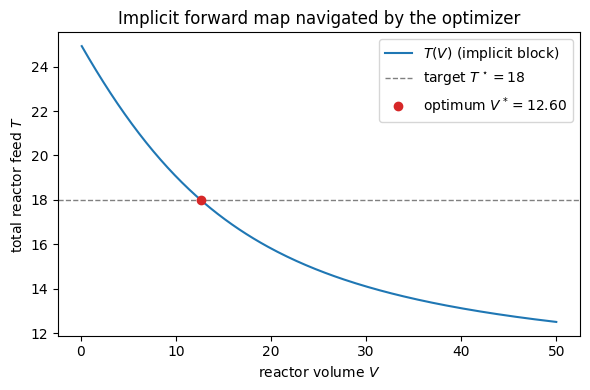

In [3]:
def T_of_V(Vval):
    # positive root of (1-alpha) T^2 + (kV - F0) T - F0 kV = 0
    a, b, c = (1 - alpha), (k * Vval - F0), -F0 * k * Vval
    return (-b + np.sqrt(b**2 - 4 * a * c)) / (2 * a)


Vstar = float(r.x["V"])
print(f"analytic V for T=18 : {(alpha * T_target**2 / (T_target - F0) - T_target) / k:.4f}")
print(f"discopt V*          : {Vstar:.4f}")
print(f"T(V*) check         : {T_of_V(Vstar):.4f}  (target {T_target})")

grid = np.linspace(0.1, 50, 200)
plt.figure(figsize=(6, 4))
plt.plot(grid, [T_of_V(v) for v in grid], label="$T(V)$ (implicit block)")
plt.axhline(T_target, ls="--", color="gray", lw=1, label="target $T^\star=18$")
plt.plot([Vstar], [T_of_V(Vstar)], "o", color="C3", label=f"optimum $V^*={Vstar:.2f}$")
plt.xlabel("reactor volume $V$")
plt.ylabel("total reactor feed $T$")
plt.legend()
plt.title("Implicit forward map navigated by the optimizer")
plt.tight_layout()
plt.show()

## The contract: local, and integer-free

The node inherits discopt's opaque-AD-only contract. Adding an integer variable
to a model with an implicit block is rejected up front, because spatial
branch-and-bound has no valid relaxation for $\varphi(u)$:

In [4]:
m_bad = dm.Model()
Vb = m_bad.continuous("V", lb=0.1, ub=50.0)
m_bad.integer("stages", lb=1, ub=5)
Tb = m_bad.implicit(recycle_residual, [Vb], n_unknowns=1, x0=jnp.array([20.0]))
m_bad.minimize((Tb[0] - T_target) ** 2)

try:
    m_bad.solve()
except Exception as exc:
    print(f"rejected as expected: {type(exc).__name__}: {str(exc)[:90]}")

rejected as expected: ValueError: Model contains a dm.custom(...) AD-only user function together with integer/binary variabl


## Takeaways

- **`m.implicit(residual, u_inputs, n_unknowns, x0=)`** represents a variable
  defined by a square system $g(u, v) = 0$ as a differentiable inner solve.
- Forward: Newton with nonsingular-Jacobian and convergence gates (a failure
  surfaces as a failed evaluation rather than a wrong root). Reverse: exact
  implicit-function-theorem derivatives {cite:p}`Blondel2022`.
- It is **local-NLP-only** and rejects integers — the correct contract for an
  unrelaxable node, and the natural setting for recycle / algebraic-loop models
  {cite:p}`Biegler2010`.
- This is the primitive that enables implicit **variable aggregation** of cyclic
  blocks {cite:p}`Naik2025`, shrinking tightly-coupled models the explicit,
  acyclic elimination cannot touch.